In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.4)

import scipy.stats as sps

In [ ]:
results = np.load('results_10000.npy')

In [ ]:
results.shape

(40, 20)

In [ ]:
n_nodes = 5000
n_clusters = 3
n_iters = 40
rho_values_num = 20
rho_space = np.logspace(-np.log(n_nodes) / 4, 0, rho_values_num)

In [ ]:
results_to_evaluate_c = results

In [ ]:
rho_space_reduced = rho_space

In [ ]:
c = (np.log(results_to_evaluate_c) - np.log(rho_space_reduced).reshape(1, -1) / 2).mean()

In [ ]:
c

-1.57632545092813

In [ ]:
n_dependence = np.load('n_dependence.npy', allow_pickle=True)

In [ ]:
error_dict = n_dependence.item()

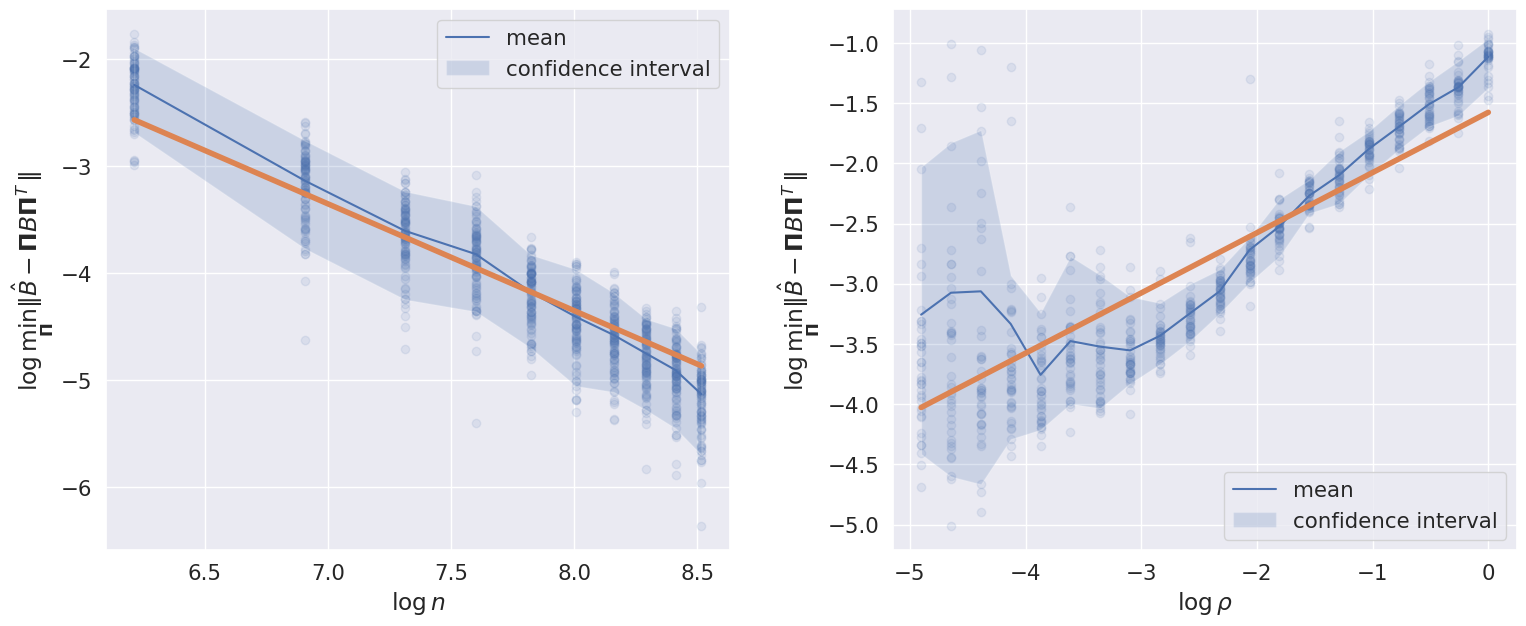

In [ ]:
fig = plt.figure(figsize=(16, 7))



plt.subplot(1, 2, 1)

plt.plot(np.log(error_dict['n_nodes']), np.log(error_dict['error_aspoc_corrected_eigenvectors'].mean(axis=1)), label='mean')

for iters_prev in range(error_dict['error_aspoc_corrected_eigenvectors'].shape[1]):
    plt.scatter(np.log(error_dict['n_nodes']), np.log(error_dict['error_aspoc_corrected_eigenvectors'][:, iters_prev]), alpha=0.1, color='b')

plt.fill_between(
    np.log(error_dict['n_nodes']),
    np.quantile(np.log(error_dict['error_aspoc_corrected_eigenvectors']), 0.95, axis=1),
    np.quantile(np.log(error_dict['error_aspoc_corrected_eigenvectors']), 0.05, axis=1),
    alpha=0.2,
    label='confidence interval'
)

c_n = (np.log(error_dict['error_aspoc_corrected_eigenvectors'].mean(axis=1)) + np.log(error_dict['n_nodes'])).mean()

plt.plot(np.log(error_dict['n_nodes']), c_n - np.log(error_dict['n_nodes']), linewidth=4)

plt.legend()

plt.xlabel(r'$\log n$')
plt.ylabel(r'$\log \min_{\mathbf{\Pi}} \Vert \hat{B} - \mathbf{\Pi} B \mathbf{\Pi}^T \Vert$')


plt.subplot(1, 2, 2)

errors = results

for iters_prev in range(results.shape[0]):
    plt.scatter(np.log(rho_space), np.log(errors[iters_prev]), alpha=0.1, color='b')




plt.plot(np.log(rho_space), np.log(np.mean(errors, axis=0)), label='mean')

plt.fill_between(
    np.log(rho_space),
    np.quantile(np.log(errors), 0.95, axis=0),
    np.quantile(np.log(errors), 0.05, axis=0),
    alpha=0.2,
    label='confidence interval'
)

plt.plot(np.log(rho_space), c + np.log(rho_space) / 2, linewidth=4)

plt.xlabel(r'$\log \rho$')
plt.ylabel(r'$\log \min_{\mathbf{\Pi}} \Vert \hat{B} - \mathbf{\Pi} B \mathbf{\Pi}^T \Vert$')

plt.legend()

plt.tight_layout(pad=2)

plt.savefig('verification.pdf', bbox_inches='tight')

plt.show()

In [ ]:
sps.linregress(np.log(rho_space), np.log(np.mean(results, axis=0)))

LinregressResult(slope=0.47652840089378595, intercept=-1.5298282052626146, rvalue=0.8784404825231886, pvalue=3.512487369183081e-07, stderr=0.06109890099082422, intercept_stderr=0.17521265557175328)

In [ ]:
sps.linregress(np.log(error_dict['n_nodes']), np.log(error_dict['error_aspoc_corrected_eigenvectors'].mean(axis=1)))

LinregressResult(slope=-1.2172926835234457, intercept=5.328091505994227, rvalue=-0.9982908073609603, pvalue=3.726070619441585e-11, stderr=0.025195199317985396, intercept_stderr=0.19542118249521678)